<a href="https://colab.research.google.com/github/sradha8658/Sales-Performance-Revenue-Analysis-Dashboard/blob/main/Sales_Performance_Revenue_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1.import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

# Better chart appearance
plt.rcParams['figure.figsize'] = (10,5)
sns.set_style('whitegrid')

2.Create a realistic sales dataset

In [4]:
np.random.seed(42)

n = 12000

regions = ['North', 'South', 'East', 'West']
products = ['Laptop', 'Mobile', 'Tablet', 'Monitor', 'Keyboard']
customers = [f'CUST_{i}' for i in range(1, 2001)]

df = pd.DataFrame({
    'Order_ID': range(1, n+1),
    'Region': np.random.choice(regions, n),
    'Product': np.random.choice(products, n),
    'Customer_ID': np.random.choice(customers, n),
    'Quantity': np.random.randint(1, 6, n),
    'Unit_Price': np.random.randint(500, 50000, n),
    'Order_Date': pd.date_range('2025-01-01', periods=n, freq='H')
})

df['Revenue'] = df['Quantity'] * df['Unit_Price']

df.head()

/tmp/ipykernel_1240/3029062494.py:16: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  'Order_Date': pd.date_range('2025-01-01', periods=n, freq='H')


,Order_ID,Region,Product,Customer_ID,Quantity,Unit_Price,Order_Date,Revenue
0,1,East,Laptop,CUST_266,4,16355,2025-01-01 00:00:00,65420
1,2,West,Laptop,CUST_1397,4,27236,2025-01-01 01:00:00,108944
2,3,North,Tablet,CUST_1176,2,1835,2025-01-01 02:00:00,3670
3,4,East,Keyboard,CUST_976,4,27692,2025-01-01 03:00:00,110768
4,5,East,Keyboard,CUST_1619,4,28794,2025-01-01 04:00:00,115176


3.save the database

In [5]:
df.to_csv('sales_data.csv', index=False)

print('Dataset saved successfully')

Dataset saved successfully


4.Data cleaning

In [7]:
df.isnull().sum()
before = len(df)

df = df.drop_duplicates()

after = len(df)

print('Rows before:', before)
print('Rows after :', after)

Rows before: 12000
Rows after : 12000


5.fix datatype

In [8]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Order_ID     12000 non-null  int64         
 1   Region       12000 non-null  object        
 2   Product      12000 non-null  object        
 3   Customer_ID  12000 non-null  object        
 4   Quantity     12000 non-null  int64         
 5   Unit_Price   12000 non-null  int64         
 6   Order_Date   12000 non-null  datetime64[ns]
 7   Revenue      12000 non-null  int64         
dtypes: datetime64[ns](1), int64(4), object(3)
memory usage: 750.1+ KB


6.Create sql database

In [9]:
conn = sqlite3.connect('sales.db')

df.to_sql('sales', conn, if_exists='replace', index=False)

print('SQL database created')

SQL database created


7.Total revenue by region

In [10]:
query = '''
SELECT Region,
       ROUND(SUM(Revenue),2) AS Total_Revenue
FROM sales
GROUP BY Region
ORDER BY Total_Revenue DESC;
'''

region_revenue = pd.read_sql(query, conn)
region_revenue

,Region,Total_Revenue
0,North,232385922.0
1,West,230148497.0
2,East,229601494.0
3,South,223547748.0


8.Top 5 products

In [11]:
query = '''
SELECT Product,
       ROUND(SUM(Revenue),2) AS Revenue
FROM sales
GROUP BY Product
ORDER BY Revenue DESC
LIMIT 5;
'''

top_products = pd.read_sql(query, conn)
top_products

,Product,Revenue
0,Laptop,189006917.0
1,Mobile,185882999.0
2,Keyboard,184707691.0
3,Monitor,181096666.0
4,Tablet,174989388.0


9.Monthly sales trend

In [13]:
query = '''
SELECT strftime('%Y-%m', Order_Date) AS Month,
       ROUND(SUM(Revenue),2) AS Revenue
FROM sales
GROUP BY Month
ORDER BY Month;
'''

monthly_sales = pd.read_sql(query, conn)
monthly_sales.head()

,Month,Revenue
0,2025-01,57373025.0
1,2025-02,51682249.0
2,2025-03,54626167.0
3,2025-04,56609263.0
4,2025-05,52380062.0


10.Create KPI metrics (Power BI / DAX style)

In [14]:
total_revenue = df['Revenue'].sum()
total_orders = df['Order_ID'].nunique()
avg_order_value = total_revenue / total_orders
total_customers = df['Customer_ID'].nunique()

print(f'Total Revenue     : ₹{total_revenue:,.0f}')
print(f'Total Orders      : {total_orders:,}')
print(f'Average Order Val.: ₹{avg_order_value:,.2f}')
print(f'Total Customers   : {total_customers:,}')

Total Revenue     : ₹915,683,661
Total Orders      : 12,000
Average Order Val.: ₹76,306.97
Total Customers   : 1,995


11.Visualize revenue by region

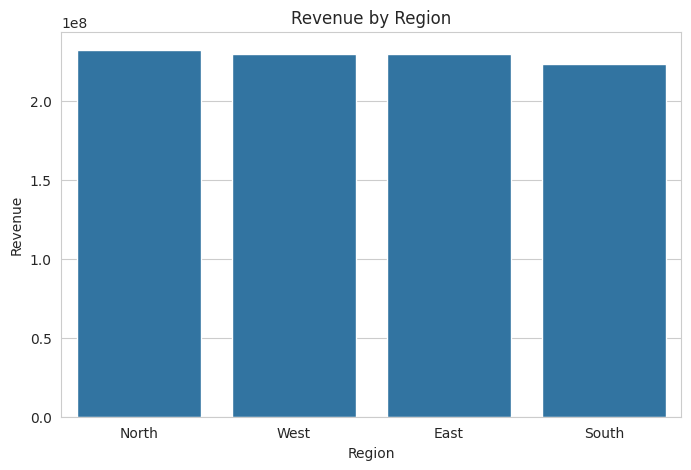

In [15]:
plt.figure(figsize=(8,5))
sns.barplot(data=region_revenue, x='Region', y='Total_Revenue')
plt.title('Revenue by Region')
plt.ylabel('Revenue')
plt.show()

12.Visualize top products

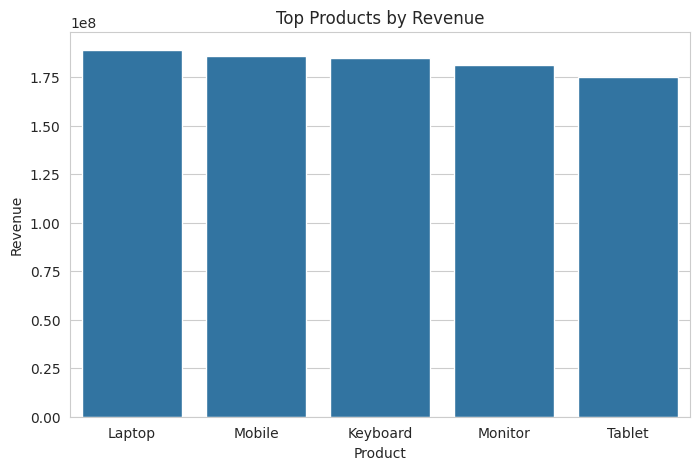

In [16]:
plt.figure(figsize=(8,5))
sns.barplot(data=top_products, x='Product', y='Revenue')
plt.title('Top Products by Revenue')
plt.ylabel('Revenue')
plt.show()

13.Monthly revenue trend

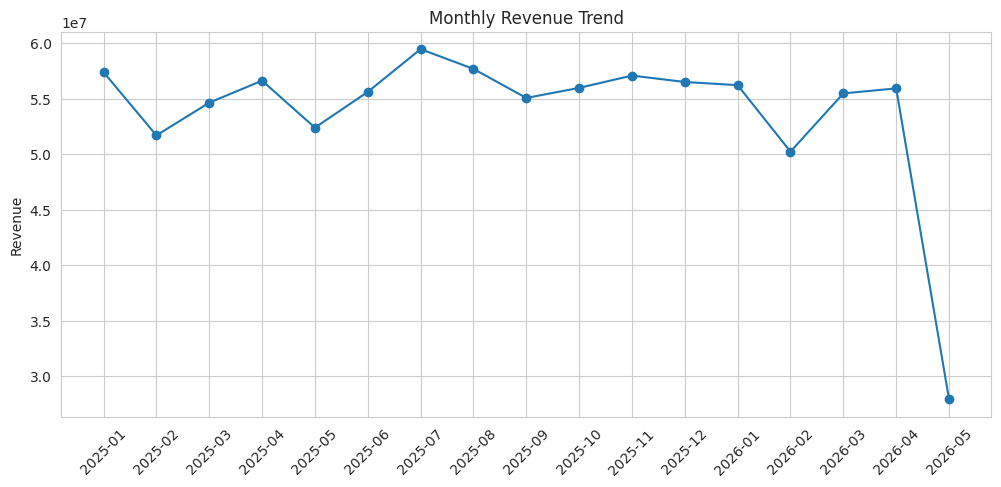

In [17]:
plt.figure(figsize=(12,5))
plt.plot(monthly_sales['Month'], monthly_sales['Revenue'], marker='o')
plt.title('Monthly Revenue Trend')
plt.xticks(rotation=45)
plt.ylabel('Revenue')
plt.show()

14.Create a dashboard-style summary

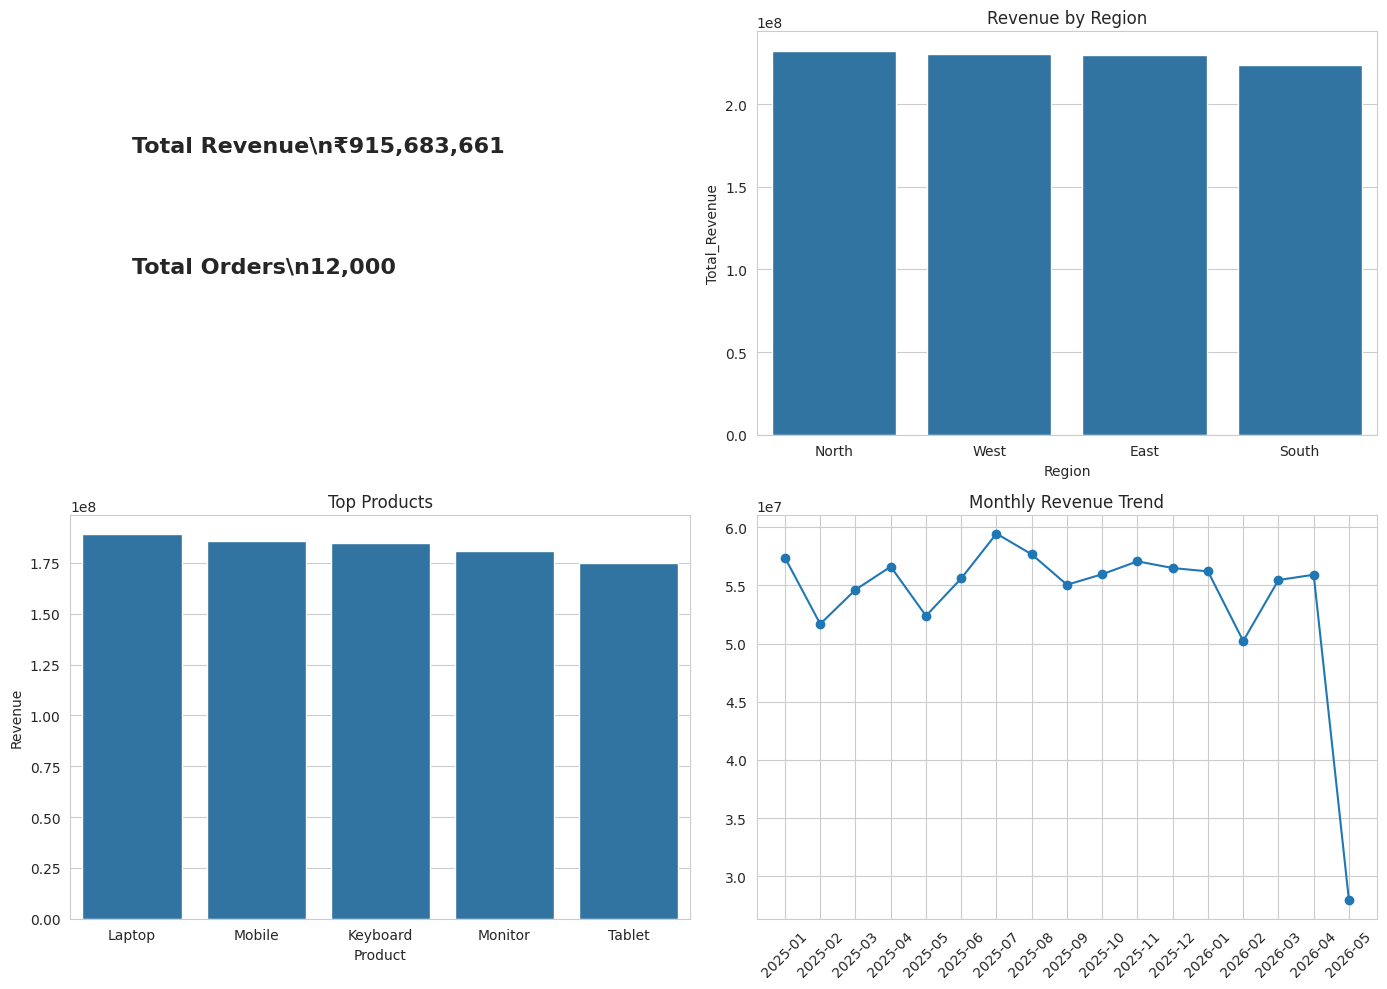

In [18]:
fig, ax = plt.subplots(2,2, figsize=(14,10))

# KPI text
ax[0,0].axis('off')
ax[0,0].text(0.1,0.7,f'Total Revenue\\n₹{total_revenue:,.0f}', fontsize=16, weight='bold')
ax[0,0].text(0.1,0.4,f'Total Orders\\n{total_orders:,}', fontsize=16, weight='bold')

# Revenue by region
sns.barplot(data=region_revenue, x='Region', y='Total_Revenue', ax=ax[0,1])
ax[0,1].set_title('Revenue by Region')

# Top products
sns.barplot(data=top_products, x='Product', y='Revenue', ax=ax[1,0])
ax[1,0].set_title('Top Products')

# Monthly trend
ax[1,1].plot(monthly_sales['Month'], monthly_sales['Revenue'], marker='o')
ax[1,1].set_title('Monthly Revenue Trend')
ax[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

15.Export cleaned data for Power BI

In [20]:
df.to_csv('cleaned_sales_data.csv', index=False)

print('Power BI ready file exported')

Power BI ready file exported
